In [1]:
import polars as pl
from pathlib import Path
ROOT = Path.cwd().parent

DATA_DIR = ROOT / "data"
# Path to your parquet file
file_path = DATA_DIR / "cve1999-2025.parquet"

# Read the parquet file
df = pl.read_parquet(file_path)

# Print the first 5 rows
print(df.head(5))

shape: (5, 384)
┌───────────┬──────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ col_0     ┆ col_1    ┆ col_2     ┆ col_3     ┆ … ┆ col_380   ┆ col_381   ┆ col_382   ┆ col_383   │
│ ---       ┆ ---      ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ f64       ┆ f64      ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════════╪══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ -0.058242 ┆ 0.143897 ┆ 0.050949  ┆ 0.044082  ┆ … ┆ 0.090575  ┆ -0.001451 ┆ -0.038536 ┆ 0.037249  │
│ 0.021119  ┆ 0.055842 ┆ -0.072913 ┆ 0.014004  ┆ … ┆ -0.063012 ┆ 0.013626  ┆ 0.037771  ┆ -0.086374 │
│ 0.002411  ┆ 0.093139 ┆ 0.0666    ┆ -0.035568 ┆ … ┆ 0.102368  ┆ 0.01956   ┆ -0.012578 ┆ 0.094946  │
│ 0.107001  ┆ 0.036205 ┆ 0.046087  ┆ 0.002699  ┆ … ┆ 0.009942  ┆ 0.122582  ┆ 0.08231   ┆ -0.021578 │
│ -0.002006 ┆ 0.051426 ┆ 0.125028  ┆ -0.007355 ┆ … ┆ 0.07509   ┆ -0.092456 

<class 'numpy.ndarray'>
=== STEP 1: BASELINE ===
23.854373 
10000
[0.18423049 0.13196125 0.20001573 0.14072986 0.26989172]
Total energy: 1833.1374492235364


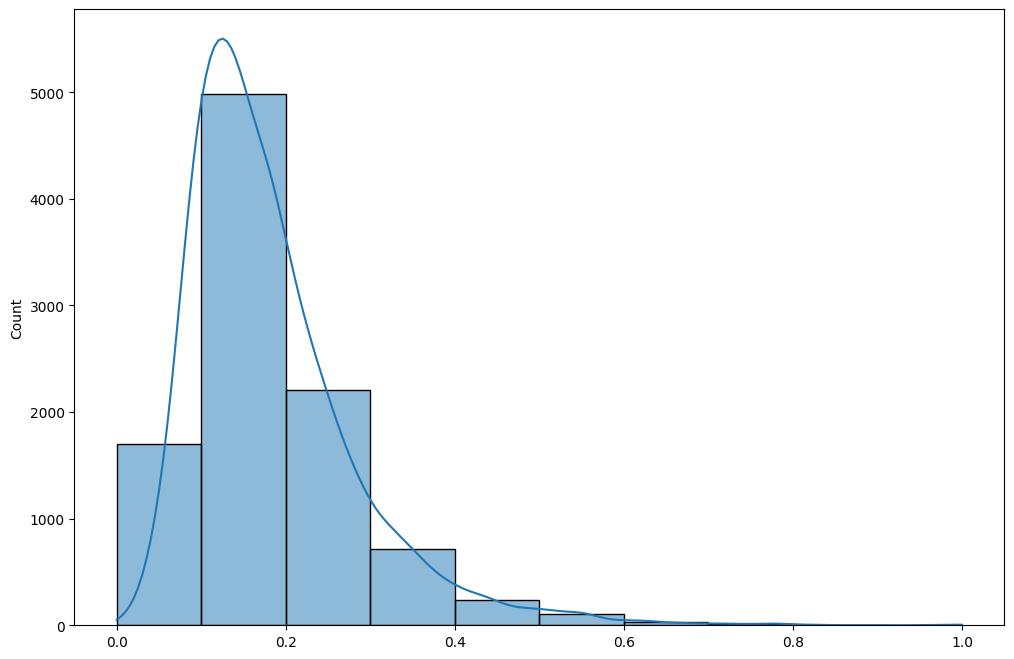

In [ ]:
from graphlaplacianoptimizer._build_direct import build_arrowspace
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import time 
import logging

logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")


SEED = 54 
n_subset = 10000

sample_df = df.sample(n_subset, seed=SEED)
arr = sample_df.to_numpy()

print(type(arr))

print("=== STEP 1: BASELINE ===")

baseline_params = {'eps': 0.25, 'k': 10, 'topk': 50, 'p': 2.0, 'sigma': 0.1}

aspace, gl = build_arrowspace(baseline_params, arr)


print(aspace.nitems)
print(aspace.lambdas()[:5])

baseline_lambdas = aspace.lambdas()
total_lmb = np.sum(aspace.lambdas())
print(f"Total energy: {total_lmb}") # sweep on top 3 best param combinations for 10, 100 ,1000, ... items

plt.figure(figsize=(12,8))
sns.histplot(baseline_lambdas, bins=10, kde=True)
plt.show()

In [ ]:
# FIX: Extract the eigenvalue (index 0 of the tuple) to ignore the node indices
baseline_lambdas_raw = build_arrowspace(baseline_params, arr)
baseline_lambdas = np.array([lam[0] for lam in baseline_lambdas_raw])

baseline_diag = {
    'fiedler': float(baseline_lambdas[1]),
    'spectral_gap': float(baseline_lambdas[2] - baseline_lambdas[1]),
    'score': spectral_score(baseline_lambdas)
}
print(f"BASELINE λ[:5]: {baseline_lambdas[:5]}")
print(f"BASELINE: {baseline_diag}")

0.659523 


TypeError: 'builtins.ArrowSpace' object is not subscriptable